In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
# IMPORTING LIBRARIES AND DATASET
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import cv2
from skimage import io, measure
import tensorflow as tf
from tensorflow.keras import Sequential, layers, optimizers
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # UPDATED IMPORT
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, LearningRateScheduler
from tensorflow.keras.applications import EfficientNetB7
import tensorflow.keras.backend as K
import random
import glob
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize
from IPython.display import display
import plotly.graph_objects as go

2025-06-21 08:52:21.726140: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750495941.901434      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750495941.956402      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
def analyze_tumor(mask, pixel_spacing=(0.5, 0.5)):
    """
    Calculate tumor characteristics from segmentation mask
    
    Parameters:
    mask (numpy.ndarray): Binary segmentation mask (0/1)
    pixel_spacing (tuple): Physical size of pixels (width, height) in mm
    
    Returns:
    dict: Tumor characteristics including shape regularity
    """
    # Label connected components
    labeled_mask = measure.label(mask)
    regions = measure.regionprops(labeled_mask)
    
    if not regions:
        return None
    
    # Get largest tumor region
    tumor_region = max(regions, key=lambda x: x.area)
    
    # Calculate area in mm²
    area_pixels = tumor_region.area
    area_mm2 = area_pixels * (pixel_spacing[0] * pixel_spacing[1])
    
    # Classify size
    if area_mm2 < 50:
        size_label = "small"
    elif area_mm2 < 200:
        size_label = "medium"
    else:
        size_label = "large"
    
    # Calculate perimeter in mm
    perimeter_pixels = tumor_region.perimeter
    perimeter_mm = perimeter_pixels * np.mean(pixel_spacing)
    
    # Calculate circularity (1 = perfect circle, lower = more irregular)
    circularity = (4 * np.pi * area_pixels) / (perimeter_pixels ** 2) if perimeter_pixels > 0 else 0
    
    # Classify shape regularity based on circularity
    if circularity > 0.8:
        shape_label = "regular"
    elif circularity > 0.6:
        shape_label = "moderately regular"
    else:
        shape_label = "irregular"
    
    # Calculate solidity (area/convex area)
    solidity = tumor_region.solidity if hasattr(tumor_region, 'solidity') else None
    
    # Calculate eccentricity (0=circle, 1=line)
    eccentricity = tumor_region.eccentricity if hasattr(tumor_region, 'eccentricity') else None
    
    return {
        'size_label': size_label,
        'area_mm2': area_mm2,
        'perimeter_mm': perimeter_mm,
        'circularity': circularity,
        'shape_label': shape_label,  # New field
        'solidity': solidity,       # Additional shape metric
        'eccentricity': eccentricity, # Additional shape metric
        'mask': tumor_region.image,
        'bbox': tumor_region.bbox
    }

In [4]:
# Load dataset
data = pd.read_csv('/kaggle/input/lgg-mri-segmentation/kaggle_3m/data.csv')
data_map = []
for sub_dir_path in glob.glob("/kaggle/input/lgg-mri-segmentation/kaggle_3m/"+"*"):
    try:
        dir_name = sub_dir_path.split('/')[-1]
        for filename in os.listdir(sub_dir_path):
            image_path = sub_dir_path + '/' + filename
            data_map.extend([dir_name, image_path])
    except Exception as e:
        print(e)

df = pd.DataFrame({"patient_id" : data_map[::2],
                   "path" : data_map[1::2]})

df_imgs = df[~df['path'].str.contains("mask")]
df_masks = df[df['path'].str.contains("mask")]

# File path line length images for later sorting
BASE_LEN = 89
END_IMG_LEN = 4
END_MASK_LEN = 9

# Data sorting
imgs = sorted(df_imgs["path"].values, key=lambda x : int(x[BASE_LEN:-END_IMG_LEN]))
masks = sorted(df_masks["path"].values, key=lambda x : int(x[BASE_LEN:-END_MASK_LEN]))

# Create final dataframe
brain_df = pd.DataFrame({"patient_id": df_imgs.patient_id.values,
                         "image_path": imgs,
                         "mask_path": masks})

def pos_neg_diagnosis(mask_path):
    value = np.max(cv2.imread(mask_path))
    if value > 0 : 
        return 1
    else:
        return 0
    
brain_df['mask'] = brain_df['mask_path'].apply(lambda x: pos_neg_diagnosis(x))

[Errno 20] Not a directory: '/kaggle/input/lgg-mri-segmentation/kaggle_3m/README.md'
[Errno 20] Not a directory: '/kaggle/input/lgg-mri-segmentation/kaggle_3m/data.csv'


In [5]:
df = pd.DataFrame({"patient_id" : data_map[::2],
                   "path" : data_map[1::2]})
df.head()

,patient_id,path
0,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
1,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
2,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
3,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...
4,TCGA_DU_7010_19860307,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...


In [6]:


brain_df['mask'].value_counts()



mask
0    2556
1    1373
Name: count, dtype: int64

In [7]:
import plotly.graph_objects as go  # using plotly to create interactive plots

fig = go.Figure([go.Bar(x=brain_df['mask'].value_counts().index, 
                        y=brain_df['mask'].value_counts(), 
                        width=[.4, .4]
                       )
                ])
fig.update_traces(marker_color='rgb(158,202,225)', marker_line_color='rgb(8,48,107)',
                  marker_line_width=4, opacity=0.4
                 )
fig.update_layout(title_text="Mask Count Plot",
                  width=700,
                  height=550,
                  yaxis=dict(
                             title_text="Count",
                             tickmode="array",
                             titlefont=dict(size=20)
                           )
                 )
fig.update_yaxes(automargin=True)
fig.show()

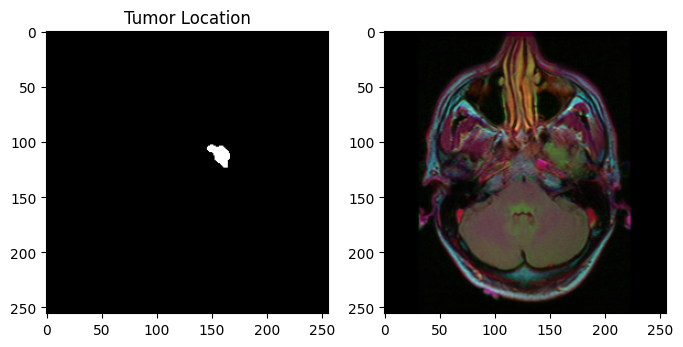

In [9]:
for i in range(len(brain_df)):
    if cv2.imread(brain_df.mask_path[i]).max() > 0:
        break

plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.imshow(cv2.imread(brain_df.mask_path[i]));
plt.title('Tumor Location')

plt.subplot(1,2,2)
plt.imshow(cv2.imread(brain_df.image_path[i]));

In [10]:
cv2.imread(brain_df.mask_path[i]).max(), cv2.imread(brain_df.mask_path[i]).min()

(255, 0)

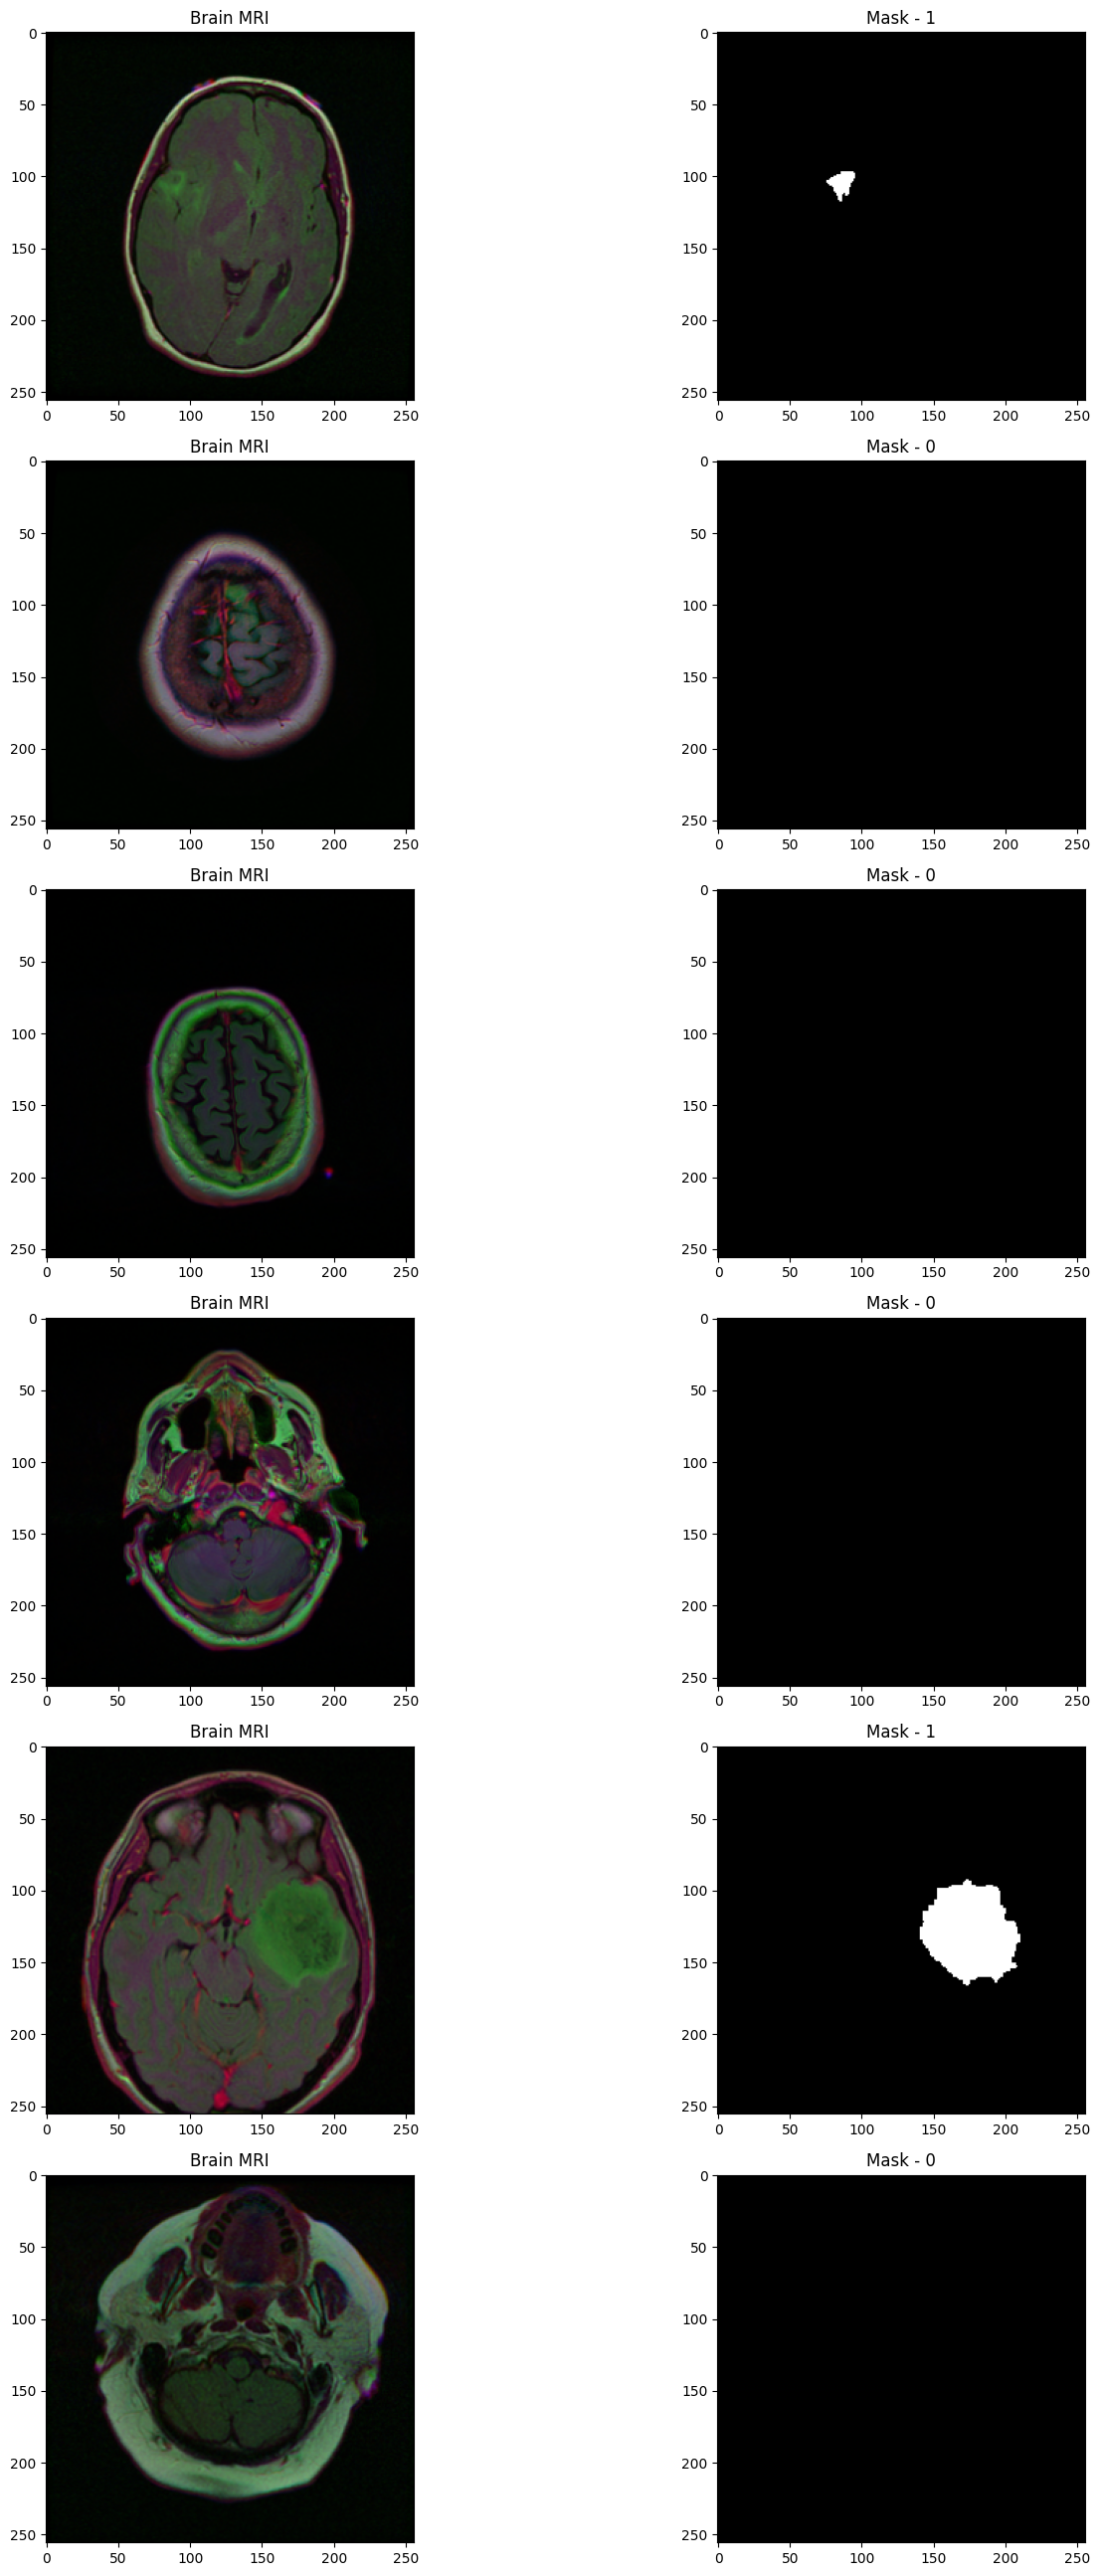

In [11]:
# Basic visualizations: Visualize the images (MRI and Mask) in the dataset separately 

fig, axs = plt.subplots(6,2, figsize=(16,26))
count = 0
for x in range(6):
  i = random.randint(0, len(brain_df)) # select a random index
  axs[count][0].title.set_text("Brain MRI") # set title
  axs[count][0].imshow(cv2.imread(brain_df.image_path[i])) # show MRI 
  axs[count][1].title.set_text("Mask - " + str(brain_df['mask'][i])) # plot title on the mask (0 or 1)
  axs[count][1].imshow(cv2.imread(brain_df.mask_path[i])) # Show corresponding mask
  count += 1

fig.tight_layout()

In [12]:
brain_df_train = brain_df.drop(columns=['patient_id'])
brain_df_train['mask'] = brain_df_train['mask'].apply(lambda x: str(x))

train, test = train_test_split(brain_df_train, test_size=0.15)
train, val = train_test_split(train, test_size=0.15)

datagen = ImageDataGenerator(rescale=1./255., validation_split=0.1)

train_generator = datagen.flow_from_dataframe(train,
                                              directory='./',
                                              x_col='image_path',
                                              y_col='mask',
                                              subset='training',
                                              class_mode='categorical',
                                              batch_size=16,
                                              shuffle=True,
                                              target_size=(256,256))
                                             
valid_generator = datagen.flow_from_dataframe(train,
                                              directory='./',
                                              x_col='image_path',
                                              y_col='mask',
                                              subset='validation',
                                              class_mode='categorical',
                                              batch_size=16,
                                              shuffle=True,
                                              target_size=(256,256))

test_datagen = ImageDataGenerator(rescale=1./255.)
test_generator = test_datagen.flow_from_dataframe(test,
                                                  directory='./',
                                                  x_col='image_path',
                                                  y_col='mask',
                                                  class_mode='categorical',
                                                  batch_size=16,
                                                  shuffle=False,
                                                  target_size=(256,256))

Found 2555 validated image filenames belonging to 2 classes.
Found 283 validated image filenames belonging to 2 classes.
Found 590 validated image filenames belonging to 2 classes.


In [12]:
# TRAIN CLASSIFIER WITH EFFICIENTNETB7
clf_model = EfficientNetB7(weights='imagenet', include_top=False, input_tensor=Input(shape=(256,256,3)))

for layer in clf_model.layers:
    layer.trainable = False

head = clf_model.output
head = AveragePooling2D(pool_size=(4,4))(head)
head = Flatten(name='Flatten')(head)
head = Dense(256, activation='relu')(head)
head = Dropout(0.3)(head)
head = Dense(256, activation='relu')(head)
head = Dropout(0.3)(head)
head = Dense(2, activation='softmax')(head)

model = Model(clf_model.input, head)
model.compile(loss = 'categorical_crossentropy', 
              optimizer='adam', 
              metrics= ["accuracy"])

earlystopping = EarlyStopping(monitor='val_loss', 
                              mode='min', 
                              verbose=1, 
                              patience=15)
checkpointer = ModelCheckpoint(filepath="clf-efficientnet-weights.keras", 
                               verbose=1, 
                               save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              mode='min',
                              verbose=1,
                              patience=10,
                              min_delta=0.0001,
                              factor=0.2)
callbacks = [checkpointer, earlystopping, reduce_lr]

h = model.fit(train_generator, 
              steps_per_epoch= train_generator.n // train_generator.batch_size, 
              epochs = 30, 
              validation_data= valid_generator, 
              validation_steps= valid_generator.n // valid_generator.batch_size, 
              callbacks=callbacks)

I0000 00:00:1750403856.681897      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750403856.682624      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


258076736/258076736 ━━━━━━━━━━━━━━━━━━━━ 9s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))



KeyboardInterrupt: 

In [15]:
from tensorflow.keras.applications.resnet50 import ResNet50
clf_model = ResNet50(weights='imagenet', include_top=False, input_tensor=Input(shape=(256,256,3)))
clf_model.summary()

I0000 00:00:1750496627.356536      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1750496627.357337      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 262, 262, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 128, 128, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 128, 128, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 128, 128, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 130, 130, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 64, 64, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 64, 64, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 64, 64, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 64, 64, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 64, 64, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 64, 64, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 64, 64, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 64, 64, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 64, 64, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [17]:
# before this i tried with trainable layer but the accuracy was less as compared
for layer in clf_model.layers:
    layers.trainable = False

In [18]:
head = clf_model.output
head = AveragePooling2D(pool_size=(4,4))(head)
head = Flatten(name='Flatten')(head)
head = Dense(256, activation='relu')(head)
head = Dropout(0.3)(head)
head = Dense(256, activation='relu')(head)
head = Dropout(0.3)(head)
head = Dense(2, activation='softmax')(head)

model = Model(clf_model.input, head)
model.compile(loss = 'categorical_crossentropy', 
              optimizer='adam', 
              metrics= ["accuracy"]
             )
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 262, 262, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 128, 128, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 128, 128, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 128, 128, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 130, 130, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 64, 64, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 64, 64, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 64, 64, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 64, 64, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 64, 64, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 64, 64, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 64, 64, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 64, 64, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 64, 64, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 25,751,426 (98.23 MB)

 Trainable params: 25,698,306 (98.03 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [19]:
earlystopping = EarlyStopping(monitor='val_loss', 
                              mode='min', 
                              verbose=1, 
                              patience=15
                             )
checkpointer = ModelCheckpoint(filepath="clf-resnet-weights.h5", 
                               verbose=1, 
                               save_best_only=True
                              )
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                              mode='min',
                              verbose=1,
                              patience=10,
                              min_delta=0.0001,
                              factor=0.2
                             )
callbacks = [checkpointer, earlystopping, reduce_lr]

In [20]:
h = model.fit(train_generator, 
              steps_per_epoch= train_generator.n // train_generator.batch_size, 
              epochs = 100, 
              validation_data= valid_generator, 
              validation_steps= valid_generator.n // valid_generator.batch_size, 
              callbacks=[checkpointer, earlystopping])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))

I0000 00:00:1750496725.296401     112 service.cc:148] XLA service 0x79d5d4004f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1750496725.297238     112 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1750496725.297260     112 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1750496729.884985     112 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1750496749.244048     112 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 332ms/step - accuracy: 0.6948 - loss: 1.0660
Epoch 1: val_loss improved from inf to 1.00409, saving model to clf-resnet-weights.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 132s 379ms/step - accuracy: 0.6950 - loss: 1.0639 - val_accuracy: 0.4044 - val_loss: 1.0041
Epoch 2/100
  1/159 ━━━━━━━━━━━━━━━━━━━━ 32s 206ms/step - accuracy: 0.8125 - loss: 0.3995

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning:

Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.




Epoch 2: val_loss did not improve from 1.00409
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8125 - loss: 0.3995 - val_accuracy: 0.4081 - val_loss: 1.1564
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - accuracy: 0.8062 - loss: 0.4251
Epoch 3: val_loss improved from 1.00409 to 0.67903, saving model to clf-resnet-weights.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 38s 237ms/step - accuracy: 0.8061 - loss: 0.4254 - val_accuracy: 0.6029 - val_loss: 0.6790
Epoch 4/100
  1/159 ━━━━━━━━━━━━━━━━━━━━ 35s 222ms/step - accuracy: 0.5000 - loss: 0.8871
Epoch 4: val_loss improved from 0.67903 to 0.66961, saving model to clf-resnet-weights.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.5000 - loss: 0.8871 - val_accuracy: 0.6029 - val_loss: 0.6696
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step - accuracy: 0.7858 - loss: 0.4882
Epoch 5: val_loss improved from 0.66961 to 0.65751, saving model to clf-resnet-weights.h5
159/159 ━━━━━━━━━━━━━━━━━━━━ 37s 235ms/step - accuracy: 0.7

In [21]:
model_json = model.to_json()
with open("clf-resnet-model.json", "w") as json_file:
    json_file.write(model_json)

In [22]:
h.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

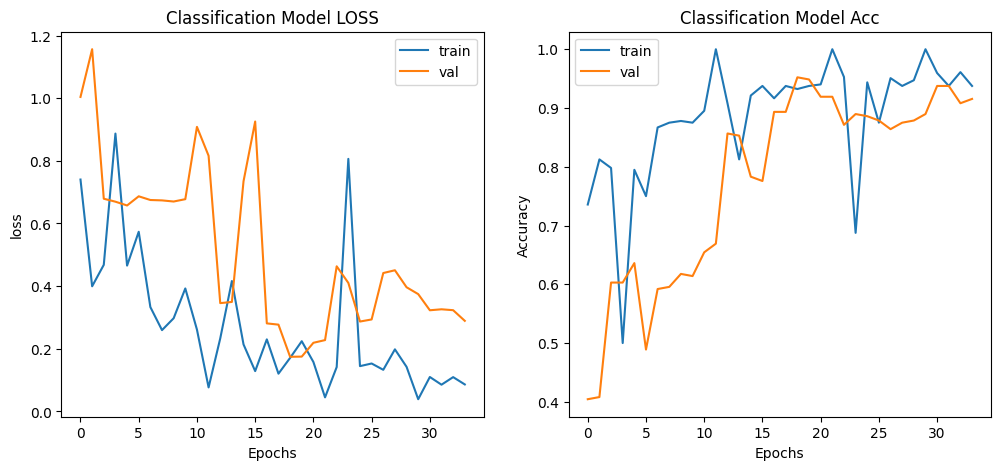

In [23]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(h.history['loss']);
plt.plot(h.history['val_loss']);
plt.title("Classification Model LOSS");
plt.ylabel("loss");
plt.xlabel("Epochs");
plt.legend(['train', 'val']);

plt.subplot(1,2,2)
plt.plot(h.history['accuracy']);
plt.plot(h.history['val_accuracy']);
plt.title("Classification Model Acc");
plt.ylabel("Accuracy");
plt.xlabel("Epochs");
plt.legend(['train', 'val']);

In [24]:
_, acc = model.evaluate(test_generator)
print("Test accuracy : {} %".format(acc*100))

37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 191ms/step - accuracy: 0.9315 - loss: 0.1950
Test accuracy : 92.20339059829712 %


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning:

The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(16, 256, 256, 3))



37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 198ms/step
0.9220338983050848
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       382
           1       0.89      0.88      0.89       208

    accuracy                           0.92       590
   macro avg       0.92      0.91      0.91       590
weighted avg       0.92      0.92      0.92       590



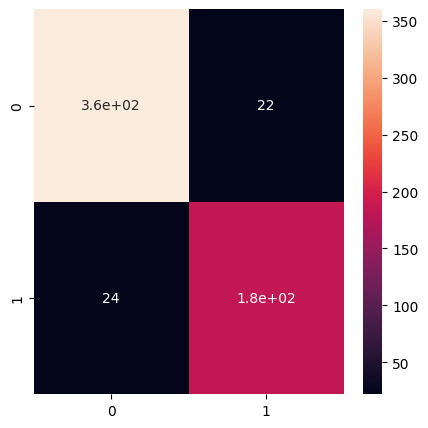

In [25]:
prediction = model.predict(test_generator)

pred = np.argmax(prediction, axis=1)
#pred = np.asarray(pred).astype('str')
original = np.asarray(test['mask']).astype('int')

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(original, pred)
print(accuracy)

cm = confusion_matrix(original, pred)

report = classification_report(original, pred, labels = [0,1])
print(report)
plt.figure(figsize = (5,5))
sns.heatmap(cm, annot=True);

In [26]:
brain_df_mask = brain_df[brain_df['mask'] == 1]
X_train, X_val = train_test_split(brain_df_mask, test_size=0.15)
X_test, X_val = train_test_split(X_val, test_size=0.5)

train_ids = list(X_train.image_path)
train_mask = list(X_train.mask_path)
val_ids = list(X_val.image_path)
val_mask = list(X_val.mask_path)

class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, ids, mask, image_dir='./', batch_size=16, img_h=256, img_w=256, shuffle=True):
        self.ids = ids
        self.mask = mask
        self.image_dir = image_dir
        self.batch_size = batch_size
        self.img_h = img_h
        self.img_w = img_w
        self.shuffle = shuffle
        self.on_epoch_end()
    
    def __len__(self):
        'Get the number of batches per epoch'
        return int(np.floor(len(self.ids)) / self.batch_size)
    
    def __getitem__(self, index):
        'Generate a batch of data'
        # Generate index of batch_size length
        indexes = self.indexes[index*self.batch_size : (index+1)*self.batch_size]
        
        # Get the ImageId corresponding to the indexes
        list_ids = [self.ids[i] for i in indexes]
        list_mask = [self.mask[i] for i in indexes]
        
        # Generate data for the X(features) and y(label)
        X, y = self.__data_generation(list_ids, list_mask)
        
        return X, y
    
    def on_epoch_end(self):
        'Updates indexes after each epoch'
        self.indexes = np.arange(len(self.ids))
        if self.shuffle:
            np.random.shuffle(self.indexes)
    
    def __data_generation(self, list_ids, list_mask):
        'Generates data corresponding to indexes in a given batch of images'
        # Create empty arrays
        X = np.empty((self.batch_size, self.img_h, self.img_w, 3))
        y = np.empty((self.batch_size, self.img_h, self.img_w, 1))
        
        # Iterate through the batch
        for i in range(len(list_ids)):
            img_path = str(list_ids[i])
            mask_path = str(list_mask[i])
            
            # Read and resize images
            img = io.imread(img_path)
            mask = io.imread(mask_path)
            
            img = cv2.resize(img, (self.img_h, self.img_w))
            img = np.array(img, dtype=np.float64)
            
            mask = cv2.resize(mask, (self.img_h, self.img_w))
            mask = np.array(mask, dtype=np.float64)
            
            # Standardize
            img -= img.mean()
            img /= img.std()
            
            mask -= mask.mean()
            mask /= mask.std()
            
            # Add to arrays
            X[i,] = img
            y[i,] = np.expand_dims(mask, axis=2)
        
        # Normalize y
        y = (y > 0).astype(int)
        
        return X, y

# Model creation functions
def resblock(X, f):
    '''
    Function for creating res block
    '''
    X_copy = X  # Copy of input
    
    # Main path
    X = Conv2D(f, kernel_size=(1,1), kernel_initializer='he_normal')(X)
    X = BatchNormalization()(X)
    X = Activation('relu')(X)
    
    X = Conv2D(f, kernel_size=(3,3), padding='same', kernel_initializer='he_normal')(X)
    X = BatchNormalization()(X)
    
    # Shortcut path
    X_copy = Conv2D(f, kernel_size=(1,1), kernel_initializer='he_normal')(X_copy)
    X_copy = BatchNormalization()(X_copy)
    
    # Adding the output from main path and short path together
    X = Add()([X, X_copy])
    X = Activation('relu')(X)
    
    return X

def upsample_concat(x, skip):
    '''
    Function for upsampling image
    '''
    X = UpSampling2D((2,2))(x)
    merge = Concatenate()([X, skip])
    
    return merge

input_shape = (256, 256, 3)
X_input = Input(input_shape)

In [27]:
input_shape = (256,256,3)
X_input = Input(input_shape) #iniating tensor of input shape

# Stage 1
conv_1 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(X_input)
conv_1 = BatchNormalization()(conv_1)
conv_1 = Conv2D(16, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv_1)
conv_1 = BatchNormalization()(conv_1)
pool_1 = MaxPool2D((2,2))(conv_1)

# stage 2
conv_2 = resblock(pool_1, 32)
pool_2 = MaxPool2D((2,2))(conv_2)

# Stage 3
conv_3 = resblock(pool_2, 64)
pool_3 = MaxPool2D((2,2))(conv_3)

# Stage 4
conv_4 = resblock(pool_3, 128)
pool_4 = MaxPool2D((2,2))(conv_4)

# Stage 5 (bottle neck)
conv_5 = resblock(pool_4, 256)

# Upsample Stage 1
up_1 = upsample_concat(conv_5, conv_4)
up_1 = resblock(up_1, 128)

# Upsample Stage 2
up_2 = upsample_concat(up_1, conv_3)
up_2 = resblock(up_2, 64)

# Upsample Stage 3
up_3 = upsample_concat(up_2, conv_2)
up_3 = resblock(up_3, 32)

# Upsample Stage 4
up_4 = upsample_concat(up_3, conv_1)
up_4 = resblock(up_4, 16)

# final output
out = Conv2D(1, (1,1), kernel_initializer='he_normal', padding='same', activation='sigmoid')(up_4)

seg_model = Model(X_input, out)
seg_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 16)   │            448 │ input_layer_2[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization       │ (None, 256, 256, 16)   │             64 │ conv2d[0][0]           │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 16)   │          2,320 │ batch_normalization[0… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_1     │ (None, 256, 256, 16)   │             64 │ conv2d_1[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 16)   │              0 │ batch_normalization_1… │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 128, 128, 32)   │            544 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_2     │ (None, 128, 128, 32)   │            128 │ conv2d_2[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation (Activation)   │ (None, 128, 128, 32)   │              0 │ batch_normalization_2… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 32)   │          9,248 │ activation[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 128, 128, 32)   │            544 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_3     │ (None, 128, 128, 32)   │            128 │ conv2d_3[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ batch_normalization_4     │ (None, 128, 128, 32)   │            128 │ conv2d_4[0][0]         │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ add (Add)                 │ (None, 128, 128, 32)   │              0 │ batch_normalization_3… │
│                           │                        │                │ batch_normalization_4… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ activation_1 (Activation) │ (None, 128, 128, 32)   │              0 │ add[0][0]              │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1      

 Total params: 1,210,513 (4.62 MB)

 Trainable params: 1,206,129 (4.60 MB)

 Non-trainable params: 4,384 (17.12 KB)

In [28]:
# Define custom loss
epsilon = 1e-5
smooth = 1

def tversky(y_true, y_pred):
    # Convert y_true to float32 to match y_pred's type
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    
    y_true_pos = K.flatten(y_true)
    y_pred_pos = K.flatten(y_pred)
    true_pos = K.sum(y_true_pos * y_pred_pos)
    false_neg = K.sum(y_true_pos * (1-y_pred_pos))
    false_pos = K.sum((1-y_true_pos)*y_pred_pos)
    alpha = 0.7
    return (true_pos + smooth)/(true_pos + alpha*false_neg + (1-alpha)*false_pos + smooth)

def focal_tversky(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    pt_1 = tversky(y_true, y_pred)
    gamma = 0.75
    return K.pow((1-pt_1), gamma)

def tversky_loss(y_true, y_pred):
    return 1 - tversky(y_true, y_pred)

# Compile and train segmentation model
adam = tf.keras.optimizers.Adam(learning_rate=0.001, epsilon=0.1)  # Reduced learning rate
seg_model.compile(optimizer=adam, 
                 loss=focal_tversky, 
                 metrics=[tversky])

# Callbacks
earlystopping = EarlyStopping(monitor='val_loss',
                            mode='min', 
                            verbose=1, 
                            patience=20)
checkpointer = ModelCheckpoint(filepath="ResUNet-bestSegModel-weights.h5", 
                             verbose=1, 
                             save_best_only=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss',
                            mode='min',
                            verbose=1,
                            patience=10,
                            min_delta=0.0001,
                            factor=0.2)

# Data generators - ensure they output float32 masks
train_data = DataGenerator(train_ids, train_mask)
val_data = DataGenerator(val_ids, val_mask)

# Training
h_seg = seg_model.fit(train_data, 
                    epochs=150,
                    validation_data=val_data,
                    callbacks=[checkpointer, earlystopping, reduce_lr])

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



Epoch 1/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - loss: 0.9538 - tversky: 0.0611

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.




Epoch 1: val_loss improved from inf to 0.94213, saving model to ResUNet-bestSegModel-weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 56s 227ms/step - loss: 0.9538 - tversky: 0.0611 - val_loss: 0.9421 - val_tversky: 0.0764 - learning_rate: 0.0010
Epoch 2/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - loss: 0.9451 - tversky: 0.0725
Epoch 2: val_loss improved from 0.94213 to 0.93892, saving model to ResUNet-bestSegModel-weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 168ms/step - loss: 0.9451 - tversky: 0.0725 - val_loss: 0.9389 - val_tversky: 0.0806 - learning_rate: 0.0010
Epoch 3/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.9368 - tversky: 0.0833
Epoch 3: val_loss improved from 0.93892 to 0.93134, saving model to ResUNet-bestSegModel-weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 12s 165ms/step - loss: 0.9368 - tversky: 0.0834 - val_loss: 0.9313 - val_tversky: 0.0905 - learning_rate: 0.0010
Epoch 4/150
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - loss: 0.9263 - tversky: 0.0970
Epoch 4: val_loss improve

In [29]:
# saving model achitecture in json file
seg_model_json = seg_model.to_json()
with open("ResUNet-best-seg-model.json", "w") as json_file:
    json_file.write(seg_model_json)

In [30]:
h.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

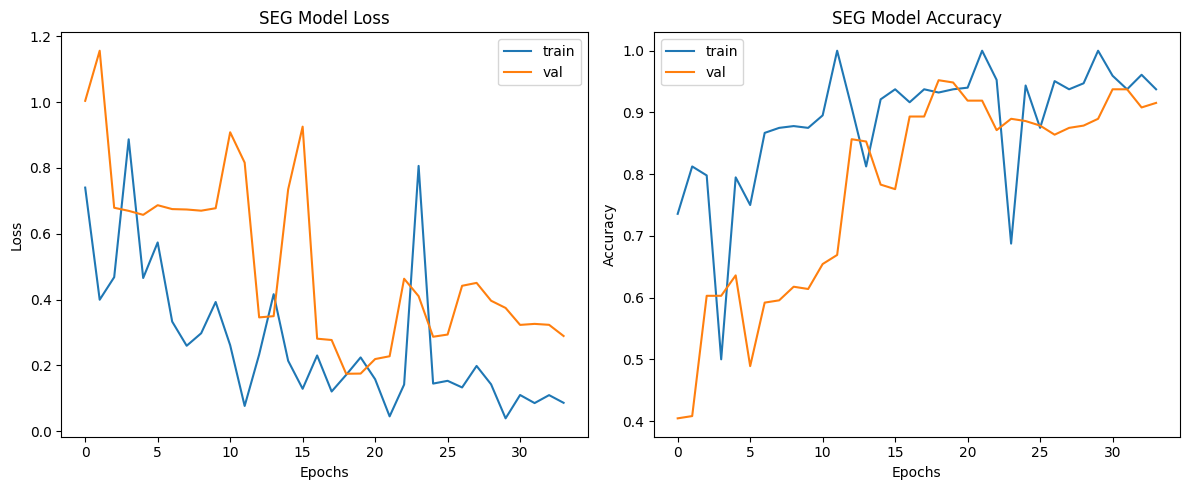

In [34]:
plt.figure(figsize=(12,5))

# Plot loss
plt.subplot(1,2,1)
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'])
plt.title("SEG Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend(['train', 'val'])

# Plot metric - adjust the key based on what print(h.history.keys()) shows
plt.subplot(1,2,2)
# Try these common alternatives if 'tversky' doesn't exist:
if 'accuracy' in h.history:
    plt.plot(h.history['accuracy'])
    plt.plot(h.history['val_accuracy'])
    metric_name = 'Accuracy'
elif 'dice_coef' in h.history:
    plt.plot(h.history['dice_coef'])
    plt.plot(h.history['val_dice_coef'])
    metric_name = 'Dice Coefficient'
elif 'iou_score' in h.history:
    plt.plot(h.history['iou_score'])
    plt.plot(h.history['val_iou_score'])
    metric_name = 'IoU Score'
else:
    # If none of the above, use the first metric that isn't loss
    for key in h.history.keys():
        if not key.startswith('val_') and key != 'loss':
            plt.plot(h.history[key])
            plt.plot(h.history[f'val_{key}'])
            metric_name = key.replace('_', ' ').title()
            break

plt.title(f"SEG Model {metric_name}")
plt.ylabel(metric_name)
plt.xlabel("Epochs")
plt.legend(['train', 'val'])

plt.tight_layout()
plt.show()

The Tversky index is a similarity measure used in segmentation tasks that generalizes both the Dice coefficient and Jaccard index (IoU). It's particularly useful for imbalanced datasets (like tumor segmentation where most pixels are background).

In [35]:


test_ids = list(X_test.image_path)
test_mask = list(X_test.mask_path)
test_data = DataGenerator(test_ids, test_mask)
_, tv = seg_model.evaluate(test_data)
print("Segmentation tversky is {:.2f}%".format(tv*100))



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning:

Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.



6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step - loss: 0.2141 - tversky: 0.8716
Segmentation tversky is 86.93%


In [56]:
def prediction(test, model, model_seg):
    # Create empty lists for results
    image_id, mask_list, has_mask = [], [], []
    size_labels,shape_labels, areas, perimeters, circularities = [], [], [], [], []
    all_masks = []
    
    # Pixel spacing assumption (modify if you have real DICOM metadata)
    PIXEL_SPACING = (0.5, 0.5)  # mm per pixel
    
    for path in test.image_path:
        # Read and preprocess image
        img = io.imread(path)
        img_norm = img / 255.0
        img_resized = cv2.resize(img_norm, (256, 256))
        img_input = np.expand_dims(img_resized, axis=0)
        
        # Classification prediction
        is_defect = model.predict(img_input, verbose=0)
        
        if np.argmax(is_defect) == 0:  # No tumor
            image_id.append(path)
            has_mask.append(0)
            mask_list.append(None)
            size_labels.append(None)
            shape_labels.append(None)
            areas.append(None)
            perimeters.append(None)
            circularities.append(None)
            all_masks.append(None)
            continue
        
        # Segmentation prediction
        seg_input = cv2.resize(img, (256, 256))
        seg_input = (seg_input - seg_input.mean()) / seg_input.std()
        seg_input = np.expand_dims(seg_input, axis=0)
        
        pred_mask = model_seg.predict(seg_input, verbose=0)[0]
        binary_mask = (pred_mask.squeeze() > 0.5).astype(np.uint8)
        
        if binary_mask.sum() == 0:  # No tumor found in mask
            image_id.append(path)
            has_mask.append(0)
            mask_list.append(None)
            size_labels.append(None)
            shape_labels.append(None)
            areas.append(None)
            perimeters.append(None)
            circularities.append(None)
            all_masks.append(None)
        else:
            # Analyze tumor
            tumor_info = analyze_tumor(binary_mask, PIXEL_SPACING)
            
            image_id.append(path)
            has_mask.append(1)
            mask_list.append(pred_mask)
            
            if tumor_info:
                size_labels.append(tumor_info['size_label'])
                shape_labels.append(tumor_info['shape_label'])
                areas.append(tumor_info['area_mm2'])
                perimeters.append(tumor_info['perimeter_mm'])
                circularities.append(tumor_info['circularity'])
                all_masks.append(tumor_info['mask'])
            else:
                size_labels.append(None)
                shape_labels.append(None)
                areas.append(None)
                perimeters.append(None)
                circularities.append(None)
                all_masks.append(None)
    
    return pd.DataFrame({
        'image_path': image_id,
        'predicted_mask': mask_list,
        'tumor_mask': all_masks,
        'has_mask': has_mask,
        'size_label': size_labels,
        'shape_label': shape_labels,
        'area_mm2': areas,
        'perimeter_mm': perimeters,
        'circularity': circularities
    })

# Run prediction pipeline
df_pred = prediction(test, model, seg_model)
df_pred = test.merge(df_pred, on='image_path')

In [57]:
df_pred = prediction(test, model, seg_model)
df_pred

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in less

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in greater



,image_path,predicted_mask,tumor_mask,has_mask,size_label,shape_label,area_mm2,perimeter_mm,circularity
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,None,None,0,None,None,NaN,NaN,NaN
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,"[[[5.0924205e-05], [0.000111288595], [4.436366...","[[False, False, False, False, False, False, Fa...",1,large,moderately regular,565.00,94.547727,0.794248
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,None,None,0,None,None,NaN,NaN,NaN
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,"[[[4.7548197e-05], [0.00012503669], [5.365543e...","[[False, False, False, False, False, False, Fa...",1,large,regular,276.50,65.112698,0.819547
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,"[[[4.2252206e-05], [9.996291e-05], [4.722073e-...","[[False, False, False, True, True, True, True,...",1,large,moderately regular,273.00,71.577164,0.669612
...,...,...,...,...,...,...,...,...,...
585,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,"[[[4.2977677e-05], [9.640044e-05], [3.9633713e...","[[False, False, False, False, False, False, Fa...",1,large,moderately regular,784.50,126.618795,0.614903
586,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,"[[[4.4607506e-05], [0.00010499616], [4.8616985...","[[False, False, False, False, False, False, Fa...",1,large,moderately regular,619.75,103.997475,0.720080
587,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,None,None,0,None,None,NaN,NaN,NaN
588,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,None,None,0,None,None,NaN,NaN,NaN


In [58]:


# merging original and prediction df
df_pred = test.merge(df_pred, on='image_path')
df_pred.head(10)



/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning:

invalid value encountered in greater

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in less

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning:

invalid value encountered in greater



,image_path,mask_path,mask,predicted_mask,tumor_mask,has_mask,size_label,shape_label,area_mm2,perimeter_mm,circularity
0,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,None,None,0,None,None,NaN,NaN,NaN
1,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1,"[[[5.0924205e-05], [0.000111288595], [4.436366...","[[False, False, False, False, False, False, Fa...",1,large,moderately regular,565.0,94.547727,0.794248
2,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,None,None,0,None,None,NaN,NaN,NaN
3,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1,"[[[4.7548197e-05], [0.00012503669], [5.365543e...","[[False, False, False, False, False, False, Fa...",1,large,regular,276.5,65.112698,0.819547
4,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,1,"[[[4.2252206e-05], [9.996291e-05], [4.722073e-...","[[False, False, False, True, True, True, True,...",1,large,moderately regular,273.0,71.577164,0.669612
5,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,None,None,0,None,None,NaN,NaN,NaN
6,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,None,None,0,None,None,NaN,NaN,NaN
7,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,None,None,0,None,None,NaN,NaN,NaN
8,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,None,None,0,None,None,NaN,NaN,NaN
9,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,/kaggle/input/lgg-mri-segmentation/kaggle_3m/T...,0,None,None,0,None,None,NaN,NaN,NaN


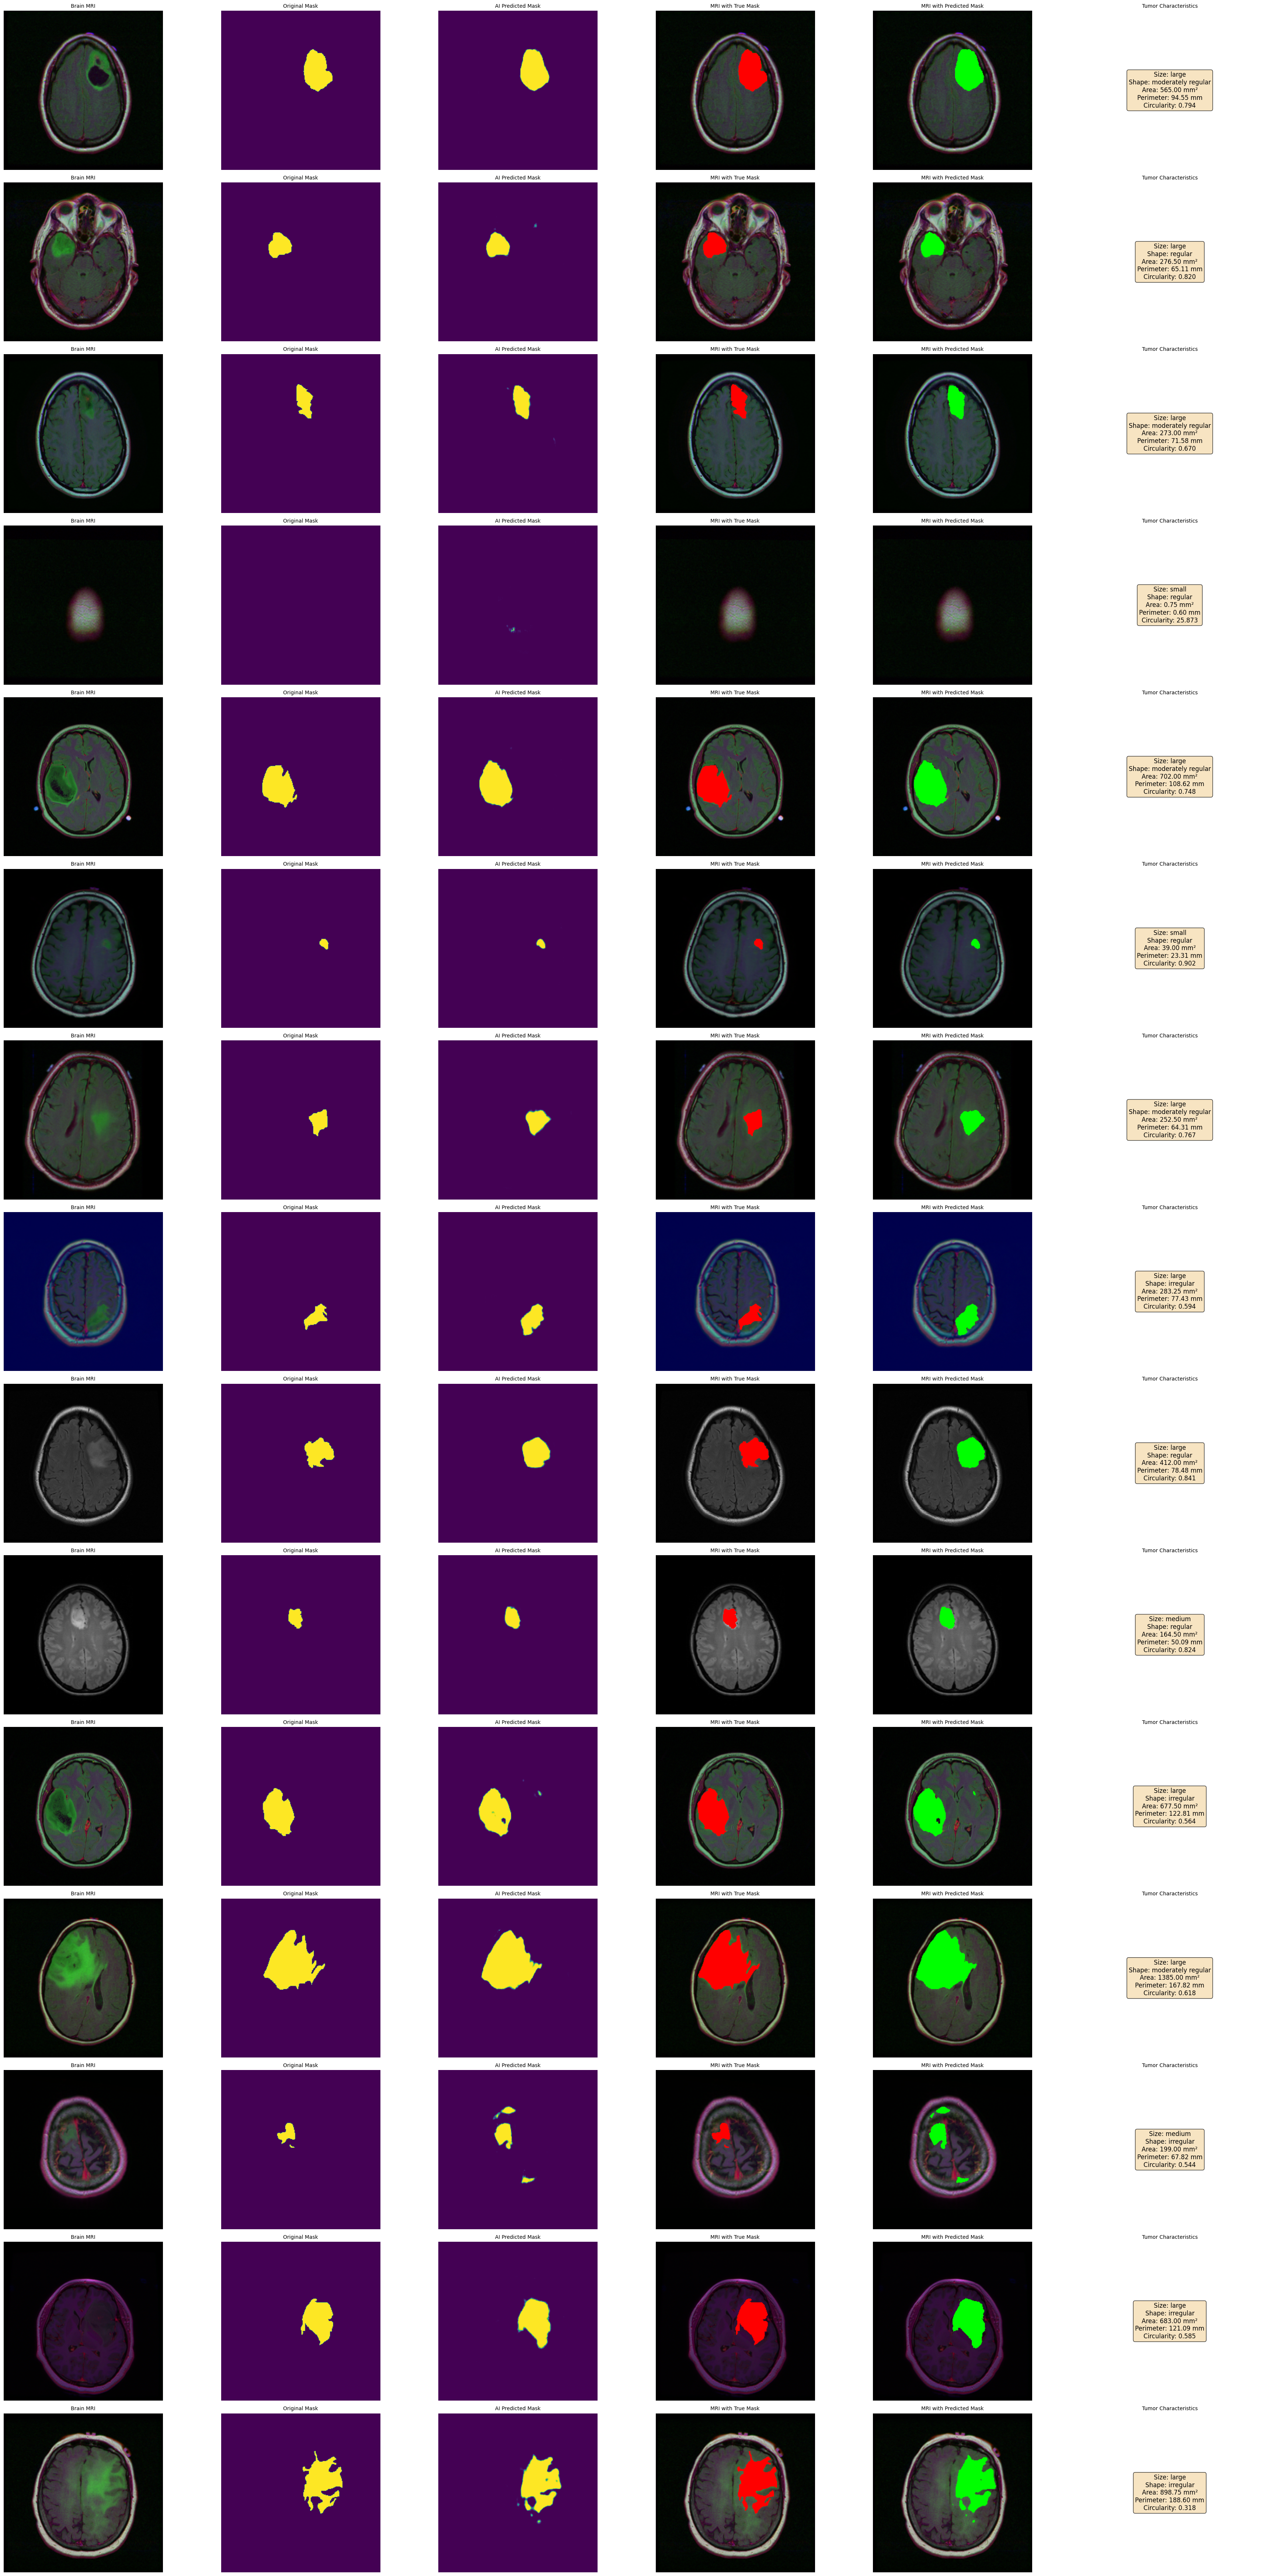


TUMOR CHARACTERISTICS SUMMARY:
Image: TCGA_DU_5872_19950223_47.tif
- Size: large
- Shape: moderately regular
- Area: 565.00 mm²
- Perimeter: 94.55 mm
- Circularity: 0.794
--------------------------------------------------
Image: TCGA_DU_6399_19830416_15.tif
- Size: large
- Shape: regular
- Area: 276.50 mm²
- Perimeter: 65.11 mm
- Circularity: 0.820
--------------------------------------------------
Image: TCGA_DU_7309_19960831_25.tif
- Size: large
- Shape: moderately regular
- Area: 273.00 mm²
- Perimeter: 71.58 mm
- Circularity: 0.670
--------------------------------------------------
Image: TCGA_DU_5872_19950223_66.tif
- Size: small
- Shape: regular
- Area: 0.75 mm²
- Perimeter: 0.60 mm
- Circularity: 25.873
--------------------------------------------------
Image: TCGA_FG_6691_20020405_27.tif
- Size: large
- Shape: moderately regular
- Area: 702.00 mm²
- Perimeter: 108.62 mm
- Circularity: 0.748
--------------------------------------------------
Image: TCGA_DU_A5TT_19980318_40.tif


In [59]:
count = 0
fig, axs = plt.subplots(15, 6, figsize=(36, 70))

for i in range(len(df_pred)):
    if df_pred.has_mask[i] == 1 and count < 15:
        # Original MRI
        img = io.imread(df_pred.image_path[i])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[count][0].imshow(img)
        axs[count][0].set_title('Brain MRI', fontsize=10)
        axs[count][0].axis('off')
        
        # Original Mask
        true_mask = io.imread(df_pred.mask_path[i])
        axs[count][1].imshow(true_mask)
        axs[count][1].set_title('Original Mask', fontsize=10)
        axs[count][1].axis('off')
        
        # Predicted Mask
        pred_mask = df_pred.predicted_mask[i].squeeze()
        axs[count][2].imshow(pred_mask)
        axs[count][2].set_title('AI Predicted Mask', fontsize=10)
        axs[count][2].axis('off')
        
        # MRI with True Mask
        img_true = img.copy()
        img_true[true_mask == 255] = (255, 0, 0)
        axs[count][3].imshow(img_true)
        axs[count][3].set_title('MRI with True Mask', fontsize=10)
        axs[count][3].axis('off')
        
        # MRI with Predicted Mask
        img_pred = img.copy()
        img_pred[pred_mask > 0.5] = (0, 255, 0)
        axs[count][4].imshow(img_pred)
        axs[count][4].set_title('MRI with Predicted Mask', fontsize=10)
        axs[count][4].axis('off')
        
        # Tumor Characteristics
        info_text = (f"Size: {df_pred.size_label[i]}\n" 
                     f"Shape: {df_pred.shape_label[i]}\n"
                     f"Area: {df_pred.area_mm2[i]:.2f} mm²\n"
                     f"Perimeter: {df_pred.perimeter_mm[i]:.2f} mm\n"
                     f"Circularity: {df_pred.circularity[i]:.3f}")
        
        axs[count][5].text(0.5, 0.5, info_text, 
                          ha='center', va='center', fontsize=12,
                          bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        axs[count][5].axis('off')
        axs[count][5].set_title('Tumor Characteristics', fontsize=10)
        
        count += 1
        
    if count == 15:
        break

fig.tight_layout()
plt.savefig('results_with_characteristics.png')
plt.show()

# PRINT TUMOR STATISTICS FOR ALL DETECTED TUMORS
print("\nTUMOR CHARACTERISTICS SUMMARY:")
print("="*50)
for i in range(len(df_pred)):
    if df_pred.has_mask[i] == 1 and df_pred.size_label[i] is not None:
        print(f"Image: {os.path.basename(df_pred.image_path[i])}")
        print(f"- Size: {df_pred.size_label[i]}")
        print(f"- Shape: {df_pred.shape_label[i]}")
        print(f"- Area: {df_pred.area_mm2[i]:.2f} mm²")
        print(f"- Perimeter: {df_pred.perimeter_mm[i]:.2f} mm")
        print(f"- Circularity: {df_pred.circularity[i]:.3f}")
        print("-"*50)